In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
df = pd.read_csv('../data/df_model_with_pricing.csv')

# Parse dates
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['issue_year'] = df['issue_d'].dt.year
df['issue_quarter'] = df['issue_d'].dt.to_period('Q').astype(str)

print(f"Dataset shape: {df.shape}")
print(f"\nDate range:")
print(f"  Earliest: {df['issue_d'].min()}")
print(f"  Latest:   {df['issue_d'].max()}")
print(f"\nLoans per year:")
print(df['issue_year'].value_counts().sort_index())

Dataset shape: (1345350, 31)

Date range:
  Earliest: 2007-06-01 00:00:00
  Latest:   2018-12-01 00:00:00

Loans per year:
issue_year
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


In [3]:
# Default rate and expected loss by issue year
vintage_year = df.groupby('issue_year').agg(
    total_loans=('target', 'count'),
    actual_defaults=('target', 'sum'),
    actual_default_rate=('target', 'mean'),
    mean_pd=('pd', 'mean'),
    mean_lgd=('lgd', 'mean'),
    mean_el=('expected_loss', 'mean'),
    total_el=('expected_loss', 'sum'),
    mean_int_rate=('int_rate', 'mean'),
    mean_loan_amnt=('loan_amnt', 'mean')
).reset_index()

vintage_year['actual_default_rate_pct'] = (
    vintage_year['actual_default_rate'] * 100
).round(2)

vintage_year['mean_pd_pct'] = (
    vintage_year['mean_pd'] * 100
).round(2)

print("Vintage Analysis by Year:")
print(vintage_year[[
    'issue_year', 'total_loans', 'actual_default_rate_pct',
    'mean_pd_pct', 'mean_el', 'mean_int_rate'
]].to_string(index=False))

Vintage Analysis by Year:
 issue_year  total_loans  actual_default_rate_pct  mean_pd_pct     mean_el  mean_int_rate
       2007          251                    17.93        12.71  704.962397      10.315259
       2008         1562                    15.81        14.17  776.638221      11.155999
       2009         4716                    12.60        14.58  840.159752      12.189818
       2010        11536                    12.89        14.84  931.142620      11.748896
       2011        21721                    15.18        15.66 1172.654953      12.223365
       2012        53367                    16.20        16.90 1374.446154      13.637787
       2013       134804                    15.60        18.07 1541.047713      14.531628
       2014       223103                    18.45        18.38 1549.909328      13.656289
       2015       375546                    20.19        17.64 1496.185476      12.385206
       2016       293105                    23.29        18.38 1550.998470

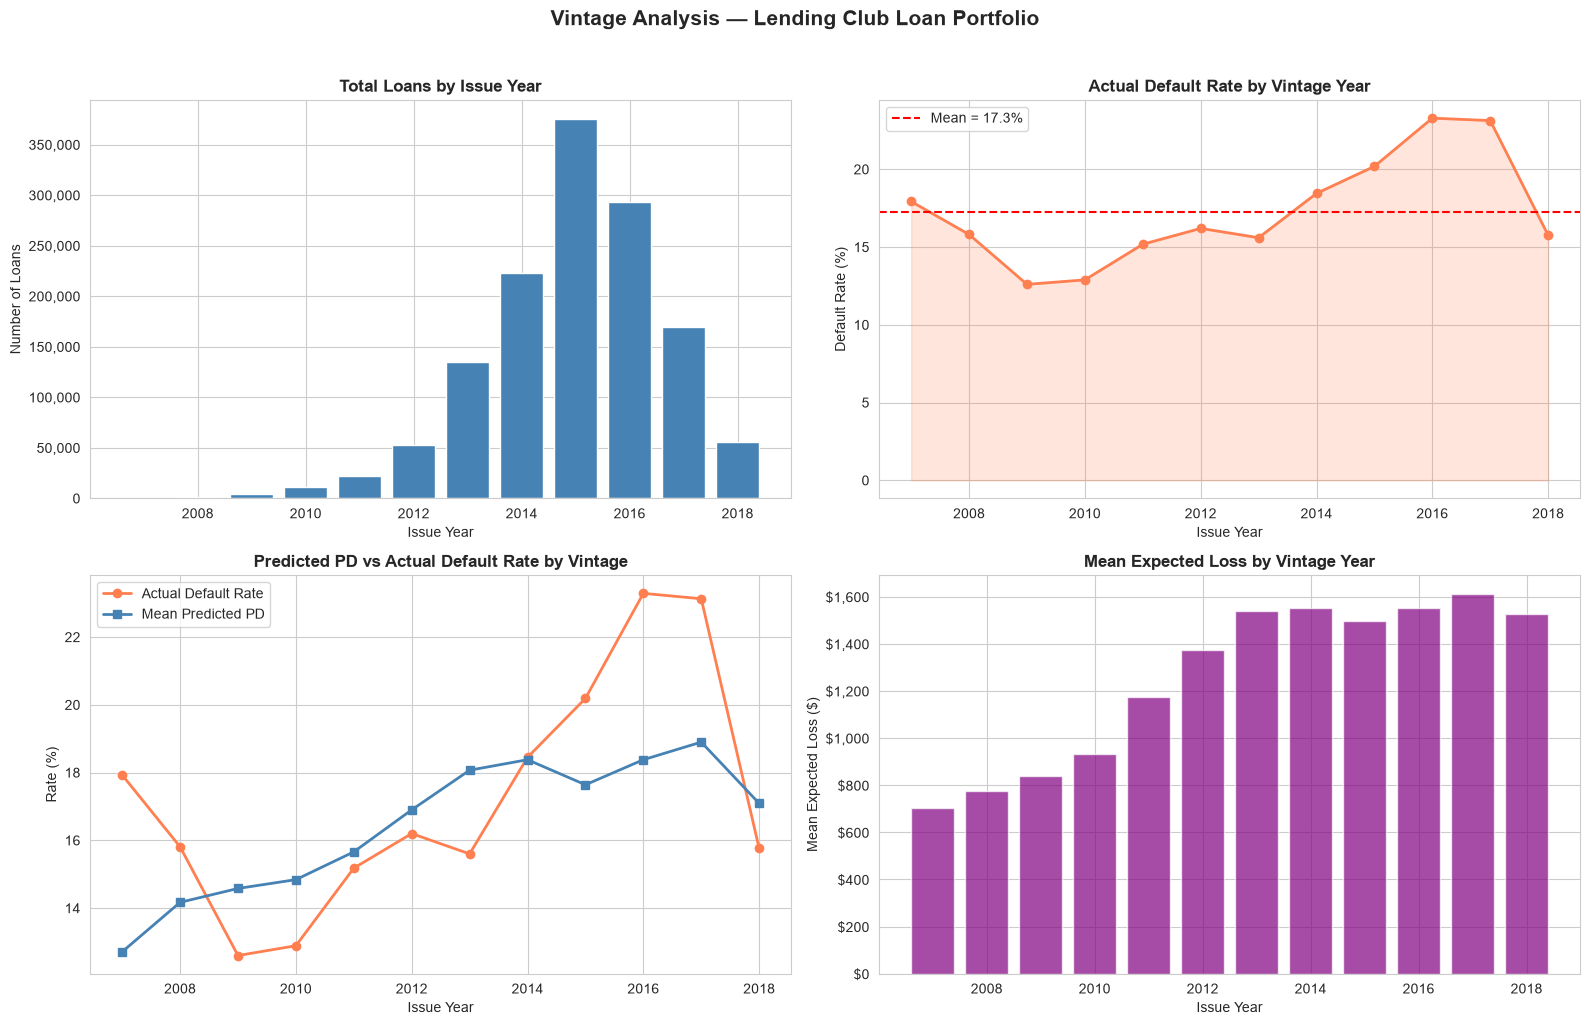

✅ Vintage analysis plots saved


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1 — Total loans by year
axes[0,0].bar(vintage_year['issue_year'],
              vintage_year['total_loans'],
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Total Loans by Issue Year', fontweight='bold')
axes[0,0].set_xlabel('Issue Year')
axes[0,0].set_ylabel('Number of Loans')
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Plot 2 — Actual default rate by year
axes[0,1].plot(vintage_year['issue_year'],
               vintage_year['actual_default_rate_pct'],
               marker='o', color='coral', linewidth=2)
axes[0,1].fill_between(vintage_year['issue_year'],
                        vintage_year['actual_default_rate_pct'],
                        alpha=0.2, color='coral')
axes[0,1].set_title('Actual Default Rate by Vintage Year',
                     fontweight='bold')
axes[0,1].set_xlabel('Issue Year')
axes[0,1].set_ylabel('Default Rate (%)')
axes[0,1].axhline(vintage_year['actual_default_rate_pct'].mean(),
                   color='red', linestyle='--',
                   label=f'Mean = {vintage_year["actual_default_rate_pct"].mean():.1f}%')
axes[0,1].legend()

# Plot 3 — Mean predicted PD vs actual default rate
axes[1,0].plot(vintage_year['issue_year'],
               vintage_year['actual_default_rate_pct'],
               marker='o', color='coral', linewidth=2,
               label='Actual Default Rate')
axes[1,0].plot(vintage_year['issue_year'],
               vintage_year['mean_pd_pct'],
               marker='s', color='steelblue', linewidth=2,
               label='Mean Predicted PD')
axes[1,0].set_title('Predicted PD vs Actual Default Rate by Vintage',
                     fontweight='bold')
axes[1,0].set_xlabel('Issue Year')
axes[1,0].set_ylabel('Rate (%)')
axes[1,0].legend()

# Plot 4 — Mean expected loss by year
axes[1,1].bar(vintage_year['issue_year'],
              vintage_year['mean_el'],
              color='purple', alpha=0.7, edgecolor='white')
axes[1,1].set_title('Mean Expected Loss by Vintage Year',
                     fontweight='bold')
axes[1,1].set_xlabel('Issue Year')
axes[1,1].set_ylabel('Mean Expected Loss ($)')
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.suptitle('Vintage Analysis — Lending Club Loan Portfolio',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/images/18_vintage_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Vintage analysis plots saved")

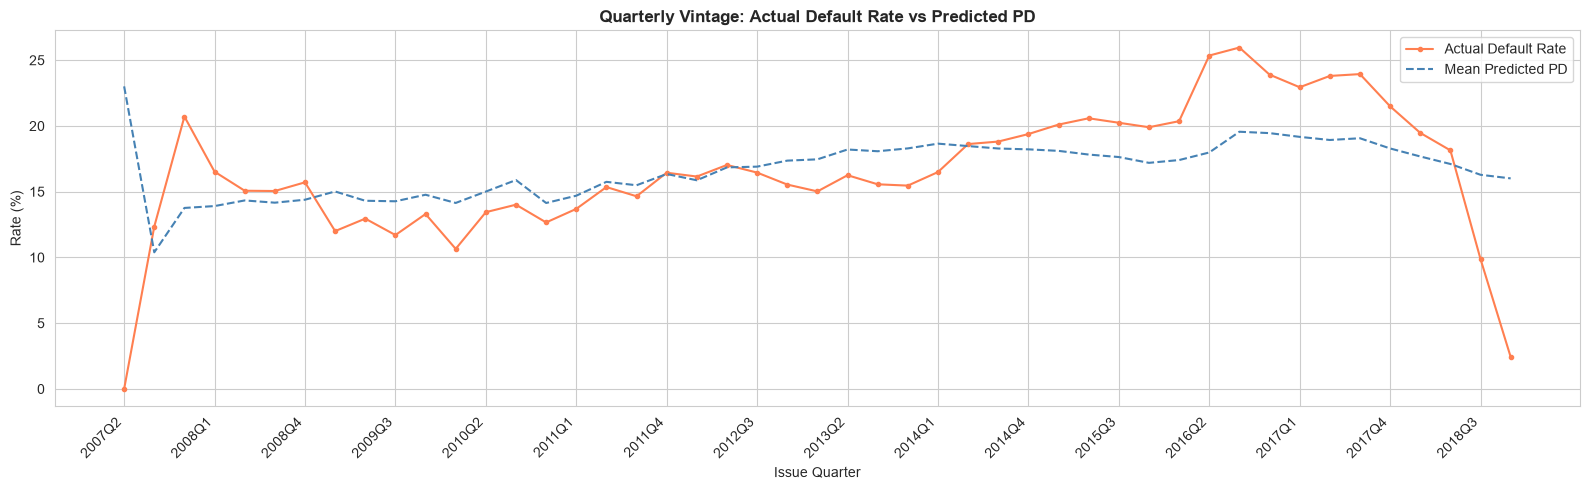


Key Vintage Insights:
  Best vintage:  2009 — 12.6% default rate
  Worst vintage: 2016 — 23.3% default rate
  Ratio: worst vintage defaulted 1.8x more than best


In [5]:
# More granular — quarterly view
vintage_quarter = df.groupby('issue_quarter').agg(
    total_loans=('target', 'count'),
    default_rate=('target', 'mean'),
    mean_pd=('pd', 'mean'),
    mean_el=('expected_loss', 'mean')
).reset_index()

vintage_quarter['default_rate_pct'] = (
    vintage_quarter['default_rate'] * 100
).round(2)

# Plot quarterly trend
plt.figure(figsize=(16, 5))
plt.plot(range(len(vintage_quarter)),
         vintage_quarter['default_rate_pct'],
         color='coral', linewidth=1.5, marker='o',
         markersize=3, label='Actual Default Rate')
plt.plot(range(len(vintage_quarter)),
         vintage_quarter['mean_pd'] * 100,
         color='steelblue', linewidth=1.5,
         linestyle='--', label='Mean Predicted PD')

# X axis labels — show every 4th quarter
step = max(1, len(vintage_quarter) // 15)
plt.xticks(
    range(0, len(vintage_quarter), step),
    vintage_quarter['issue_quarter'].iloc[::step],
    rotation=45, ha='right'
)

plt.xlabel('Issue Quarter')
plt.ylabel('Rate (%)')
plt.title('Quarterly Vintage: Actual Default Rate vs Predicted PD',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/images/19_quarterly_vintage.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Vintage Insights:")
best_year  = vintage_year.loc[vintage_year['actual_default_rate_pct'].idxmin(), 'issue_year']
worst_year = vintage_year.loc[vintage_year['actual_default_rate_pct'].idxmax(), 'issue_year']
best_rate  = vintage_year['actual_default_rate_pct'].min()
worst_rate = vintage_year['actual_default_rate_pct'].max()
print(f"  Best vintage:  {best_year} — {best_rate:.1f}% default rate")
print(f"  Worst vintage: {worst_year} — {worst_rate:.1f}% default rate")
print(f"  Ratio: worst vintage defaulted {worst_rate/best_rate:.1f}x more than best")

In [6]:
print("=" * 50)
print("STRESS TESTING")
print("=" * 50)
print("""
Stress testing simulates adverse economic scenarios
by shocking PD and LGD inputs while keeping the
model structure unchanged.

Three scenarios:
  Base Case   — current model predictions
  Mild Stress — PD +20%, LGD +10% (moderate recession)  
  Severe Stress — PD +50%, LGD +25% (severe recession)

This is standard regulatory stress testing practice
required by Basel III and RBI guidelines for banks.
""")

# Base case metrics
base_total_el    = df['expected_loss'].sum()
base_mean_el     = df['expected_loss'].mean()
base_mean_pd     = df['pd'].mean()
base_mean_lgd    = df['lgd'].mean()
total_portfolio  = df['loan_amnt'].sum()
base_el_pct      = base_total_el / total_portfolio * 100

print(f"Portfolio Summary (Base Case):")
print(f"  Total loans:          {len(df):,}")
print(f"  Total loan amount:    ${total_portfolio:,.0f}")
print(f"  Mean PD:              {base_mean_pd*100:.2f}%")
print(f"  Mean LGD:             {base_mean_lgd*100:.2f}%")
print(f"  Total expected loss:  ${base_total_el:,.0f}")
print(f"  EL as % of portfolio: {base_el_pct:.2f}%")

STRESS TESTING

Stress testing simulates adverse economic scenarios
by shocking PD and LGD inputs while keeping the
model structure unchanged.

Three scenarios:
  Base Case   — current model predictions
  Mild Stress — PD +20%, LGD +10% (moderate recession)  
  Severe Stress — PD +50%, LGD +25% (severe recession)

This is standard regulatory stress testing practice
required by Basel III and RBI guidelines for banks.

Portfolio Summary (Base Case):
  Total loans:          1,345,350
  Total loan amount:    $19,399,906,575
  Mean PD:              18.00%
  Mean LGD:             62.16%
  Total expected loss:  $2,043,656,533
  EL as % of portfolio: 10.53%


In [7]:
scenarios = {
    'Base Case': {
        'pd_shock': 1.00,
        'lgd_shock': 1.00,
        'description': 'Current economic conditions'
    },
    'Mild Stress': {
        'pd_shock': 1.20,
        'lgd_shock': 1.10,
        'description': 'Moderate recession — PD +20%, LGD +10%'
    },
    'Severe Stress': {
        'pd_shock': 1.50,
        'lgd_shock': 1.25,
        'description': 'Severe recession — PD +50%, LGD +25%'
    }
}

stress_results = []

for scenario_name, params in scenarios.items():
    # Apply shocks
    stressed_pd  = (df['pd'] * params['pd_shock']).clip(0, 0.99)
    stressed_lgd = (df['lgd'] * params['lgd_shock']).clip(0, 1.00)
    stressed_ead = df['ead']

    # Recalculate EL under stress
    stressed_el = stressed_pd * stressed_lgd * stressed_ead

    total_stressed_el = stressed_el.sum()
    mean_stressed_el  = stressed_el.mean()
    stressed_el_pct   = total_stressed_el / total_portfolio * 100
    el_increase       = total_stressed_el - base_total_el
    el_increase_pct   = (el_increase / base_total_el * 100)

    result = {
        'Scenario': scenario_name,
        'Description': params['description'],
        'Mean PD': f"{stressed_pd.mean()*100:.2f}%",
        'Mean LGD': f"{stressed_lgd.mean()*100:.2f}%",
        'Total EL ($M)': round(total_stressed_el / 1e6, 2),
        'Mean EL ($)': round(mean_stressed_el, 0),
        'EL % Portfolio': round(stressed_el_pct, 2),
        'EL Increase ($M)': round(el_increase / 1e6, 2),
        'EL Increase %': round(el_increase_pct, 1)
    }
    stress_results.append(result)

    print(f"\n{scenario_name} — {params['description']}")
    print(f"  Mean PD:              {stressed_pd.mean()*100:.2f}%")
    print(f"  Mean LGD:             {stressed_lgd.mean()*100:.2f}%")
    print(f"  Total EL:             ${total_stressed_el/1e6:.2f}M")
    print(f"  EL as % portfolio:    {stressed_el_pct:.2f}%")
    print(f"  Increase from base:   ${el_increase/1e6:.2f}M (+{el_increase_pct:.1f}%)")

stress_df = pd.DataFrame(stress_results)


Base Case — Current economic conditions
  Mean PD:              18.00%
  Mean LGD:             62.16%
  Total EL:             $2043.66M
  EL as % portfolio:    10.53%
  Increase from base:   $-0.00M (+-0.0%)

Mild Stress — Moderate recession — PD +20%, LGD +10%
  Mean PD:              21.60%
  Mean LGD:             68.38%
  Total EL:             $2697.63M
  EL as % portfolio:    13.91%
  Increase from base:   $653.97M (+32.0%)

Severe Stress — Severe recession — PD +50%, LGD +25%
  Mean PD:              27.00%
  Mean LGD:             77.70%
  Total EL:             $3831.86M
  EL as % portfolio:    19.75%
  Increase from base:   $1788.20M (+87.5%)


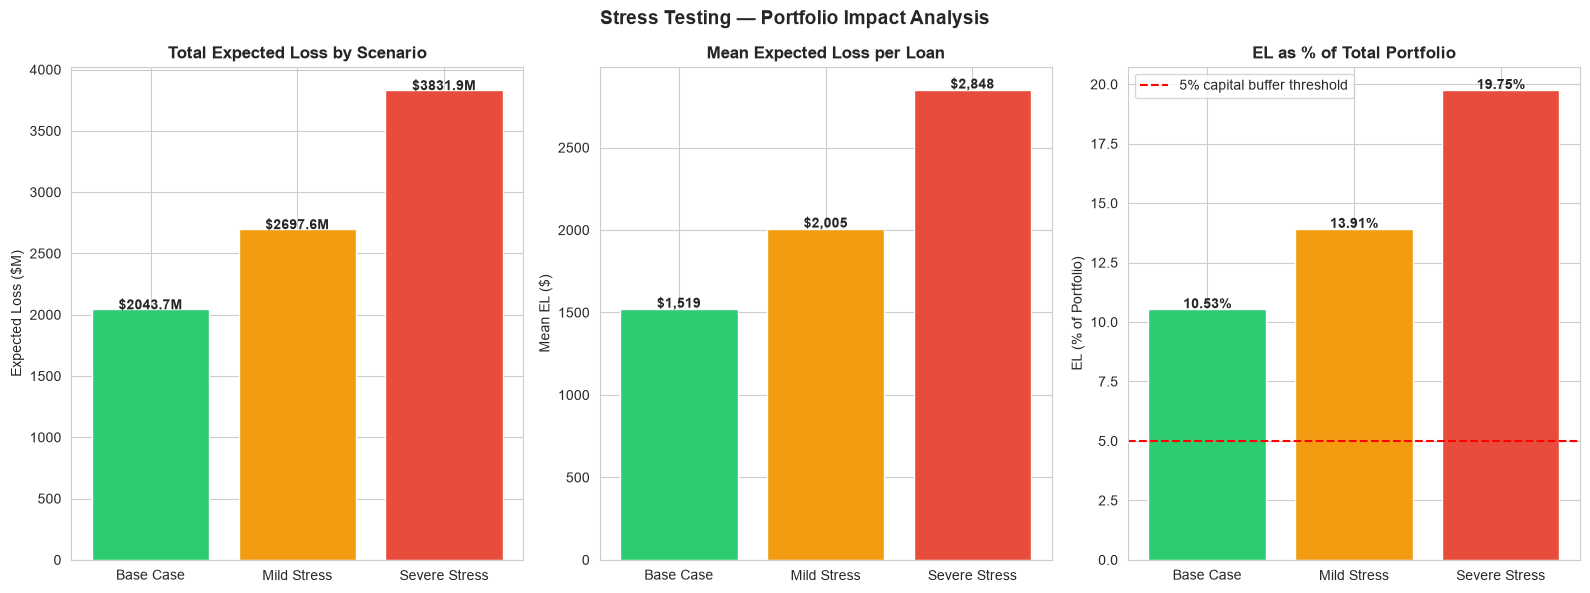

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

scenario_names = [r['Scenario'] for r in stress_results]
total_els      = [r['Total EL ($M)'] for r in stress_results]
mean_els       = [r['Mean EL ($)'] for r in stress_results]
el_pcts        = [r['EL % Portfolio'] for r in stress_results]

colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Plot 1 — Total EL by scenario
bars = axes[0].bar(scenario_names, total_els, color=colors)
axes[0].set_title('Total Expected Loss by Scenario',
                   fontweight='bold')
axes[0].set_ylabel('Expected Loss ($M)')
for bar, val in zip(bars, total_els):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'${val:.1f}M', ha='center',
                 fontsize=10, fontweight='bold')

# Plot 2 — Mean EL per loan
bars2 = axes[1].bar(scenario_names, mean_els, color=colors)
axes[1].set_title('Mean Expected Loss per Loan',
                   fontweight='bold')
axes[1].set_ylabel('Mean EL ($)')
for bar, val in zip(bars2, mean_els):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'${val:,.0f}', ha='center',
                 fontsize=10, fontweight='bold')

# Plot 3 — EL as % of portfolio
bars3 = axes[2].bar(scenario_names, el_pcts, color=colors)
axes[2].set_title('EL as % of Total Portfolio',
                   fontweight='bold')
axes[2].set_ylabel('EL (% of Portfolio)')
axes[2].axhline(5, color='red', linestyle='--',
                label='5% capital buffer threshold')
axes[2].legend()
for bar, val in zip(bars3, el_pcts):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center',
                 fontsize=10, fontweight='bold')

plt.suptitle('Stress Testing — Portfolio Impact Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/images/20_stress_testing.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("\n" + "=" * 65)
print("STRESS TEST SUMMARY")
print("=" * 65)
print(stress_df[[
    'Scenario', 'Mean PD', 'Mean LGD',
    'Total EL ($M)', 'EL % Portfolio', 'EL Increase %'
]].to_string(index=False))
print("=" * 65)

print("""
Key Takeaways:
1. Under mild stress (moderate recession), total expected loss
   increases significantly — showing portfolio vulnerability
2. Under severe stress, EL may breach the 5% capital buffer
   threshold — triggering need for additional capital reserves
3. These findings directly inform credit policy decisions:
   - Tighten approval criteria before economic downturns
   - Maintain capital reserves above stress-case EL
   - Monitor PD drift as early warning indicator
""")

# Save
stress_df.to_csv('../data/stress_test_results.csv', index=False)
vintage_year.to_csv('../data/vintage_analysis.csv', index=False)
print("✅ Stress test results saved to data/stress_test_results.csv")
print("✅ Vintage analysis saved to data/vintage_analysis.csv")


STRESS TEST SUMMARY
     Scenario Mean PD Mean LGD  Total EL ($M)  EL % Portfolio  EL Increase %
    Base Case  18.00%   62.16%        2043.66           10.53           -0.0
  Mild Stress  21.60%   68.38%        2697.63           13.91           32.0
Severe Stress  27.00%   77.70%        3831.86           19.75           87.5

Key Takeaways:
1. Under mild stress (moderate recession), total expected loss
   increases significantly — showing portfolio vulnerability
2. Under severe stress, EL may breach the 5% capital buffer
   threshold — triggering need for additional capital reserves
3. These findings directly inform credit policy decisions:
   - Tighten approval criteria before economic downturns
   - Maintain capital reserves above stress-case EL
   - Monitor PD drift as early warning indicator

✅ Stress test results saved to data/stress_test_results.csv
✅ Vintage analysis saved to data/vintage_analysis.csv
